# MOD-IV Property Data — Parcel Join

Join the statewide MOD-IV property records (2010–2025, parquet) with the `Statewide_Parcels_MODIV.gdb` GIS layer via DuckDB + GeoPandas.

In [ ]:
import geopandas as gpd
import pandas as pd
import pyarrow.parquet as pq
import duckdb
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import matplotlib.patches as mpatches
from pathlib import Path

DATA = Path("data")
GDB_PATH  = DATA / "Statewide_Parcels_MODIV.gdb"
PARQ_PATH = DATA / "property_2_2010_2025_parquet"

print("geopandas:", gpd.__version__)
print("duckdb:   ", duckdb.__version__)

geopandas: 1.0.1
duckdb:    1.2.2


## 1. Verify GIS Parcel Layer

In [3]:
# List layers in the GDB
layers = gpd.list_layers(GDB_PATH)
print("Layers in GDB:")
print(layers.to_string())


Layers in GDB:
              name geometry_type
0     Cad_pclblock  MultiPolygon
1  Cad_parcel_mod4  MultiPolygon


In [4]:
LAYER = "Cad_parcel_mod4"

con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

# Schema + row count — no full scan of geometries
info = con.execute(f"""
    SELECT * FROM ST_Read('{GDB_PATH}', layer='{LAYER}')
    LIMIT 0
""").description  # column names/types only

print(f"Layer: {LAYER!r}")
print(f"\nColumns ({len(info)}):")
for col in info:
    print(f"  {col[0]:<40} {col[1]}")


Layer: 'Cad_parcel_mod4'

Columns (45):
  PAMS_PIN                                 VARCHAR
  PCL_MUN                                  VARCHAR
  PCLBLOCK                                 VARCHAR
  PCLLOT                                   VARCHAR
  PCLQCODE                                 VARCHAR
  PCLLASTUPD                               TIMESTAMP_MS
  PIN_NODUP                                VARCHAR
  GIS_PIN                                  VARCHAR
  CD_CODE                                  VARCHAR
  PROP_CLASS                               VARCHAR
  COUNTY                                   VARCHAR
  MUN_NAME                                 VARCHAR
  PROP_LOC                                 VARCHAR
  OWNER_NAME                               VARCHAR
  ST_ADDRESS                               VARCHAR
  CITY_STATE                               VARCHAR
  ZIP_CODE                                 VARCHAR
  LAND_VAL                                 INTEGER
  IMPRVT_VAL                         

In [5]:
import pyogrio

# Instant QA — pyogrio reads GDB metadata via GDAL without loading any geometry
info = pyogrio.read_info(str(GDB_PATH), layer=LAYER)

print(f"Layer:        {LAYER!r}")
print(f"Total rows:   {info['features']:,}")
print(f"CRS:          {info['crs']}")
print(f"Geometry:     {info['geometry_type']}")
print(f"Bounds (xmin, ymin, xmax, ymax):")
print(f"  {info['total_bounds']}")
print(f"\nFields ({len(info['fields'])}):")
for name, dtype in zip(info["fields"], info["dtypes"]):
    print(f"  {name:<40} {dtype}")


Layer:        'Cad_parcel_mod4'
Total rows:   3,478,727
CRS:          COMPD_CS["NAD83 / New Jersey (ftUS) + NAVD88 height (ftUS)",PROJCS["NAD83 / New Jersey (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38.8333333333333],PARAMETER["central_meridian",-74.5],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",492125],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3424"]],VERT_CS["NAVD88 height (ftUS)",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Gravity-related height",UP

## 2. Quick Plot of Parcel Layer

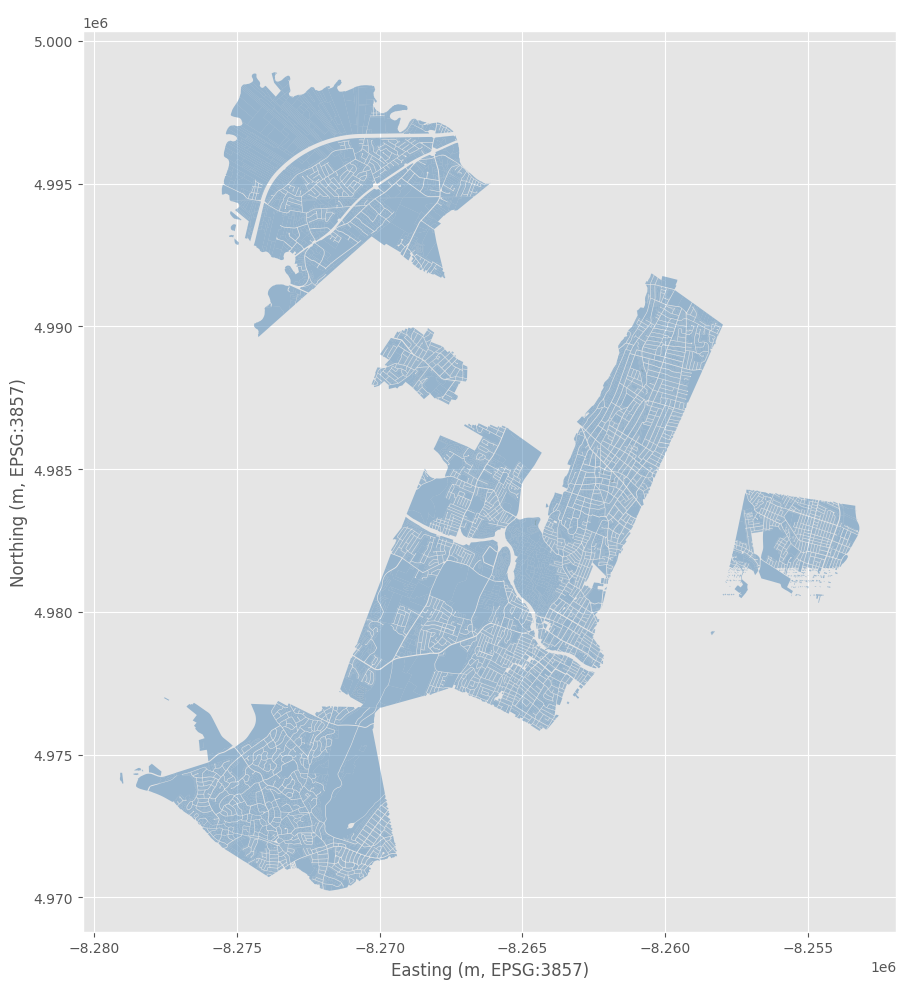

In [24]:
# Read first 50k parcels for a quick plot — max_features avoids loading all 3.4M rows
sample_gdf = gpd.read_file(
    GDB_PATH, layer=LAYER, rows=50_000, engine="pyogrio"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
sample_gdf.plot(ax=ax, facecolor="steelblue", edgecolor="none", alpha=0.5)
ax.set_title(f"{LAYER!r}  —  first 50 k parcels (sample)", fontsize=13)
ax.set_xlabel("Easting (m, EPSG:3857)")
ax.set_ylabel("Northing (m, EPSG:3857)")
ax.ticklabel_format(style="sci", scilimits=(6, 6), axis="both")
plt.tight_layout()
plt.show()

del sample_gdf  # free memory


## 3. Inspect MOD-IV Parquet Schema

## 3b. Convert GDB → GeoParquet (one-time)

DuckDB's spatial extension can't parse the WKB geometry types in this GDB directly.
We convert once to GeoParquet via geopandas/pyogrio; subsequent runs skip this step.

In [7]:
PARCELS_PARQ = DATA / "parcels_cad_mod4.parquet"

if not PARCELS_PARQ.exists():
    import time
    print("Converting GDB → GeoParquet …")
    t0 = time.time()
    gdf = gpd.read_file(GDB_PATH, layer=LAYER, engine="pyogrio")
    gdf.to_parquet(PARCELS_PARQ, index=False)
    print(f"Done in {time.time()-t0:.0f}s  →  {PARCELS_PARQ} ({PARCELS_PARQ.stat().st_size/1e9:.2f} GB)")
else:
    print(f"Already exists: {PARCELS_PARQ} ({PARCELS_PARQ.stat().st_size/1e9:.2f} GB)")


Already exists: data/parcels_cad_mod4.parquet (1.11 GB)


In [25]:
# Read schema from one partition (cheap — no data loaded)
sample_file = sorted(PARQ_PATH.glob("**/*.parquet"))[0]
schema = pq.read_schema(sample_file)

print(f"Schema from: {sample_file.relative_to(DATA)}")
print(f"Total columns: {len(schema)}\n")
for field in schema:
    print(f"  {field.name:<40} {field.type}")


Schema from: property_2_2010_2025_parquet/mod_iv_year=2010/data_0.parquet
Total columns: 126

  mod_iv_recordid                          string
  mun_code_id                              string
  mod_iv_county_name                       string
  mod_iv_munis_name                        string
  gis_pin                                  string
  county_district                          string
  property_id_blk                          string
  property_id_lot                          string
  property_id_qualifier                    string
  qualification_code_name                  string
  record_id                                string
  sub_record_id                            string
  last_trans_date_MMDDYY                   string
  last_trans_update_number                 string
  tax_acct_number                          string
  property_class                           string
  property_class_code_name                 string
  property_location                        string
  buil

In [9]:
PARCELS_PARQ = DATA / "parcels_cad_mod4.parquet"

# Read both schemas and compare case-insensitively
modiv_cols  = {f.name.lower() for f in schema}
parcel_cols = {f.name.lower() for f in pq.read_schema(PARCELS_PARQ)
               if f.name != "geometry"}

join_candidates = modiv_cols & parcel_cols
print("Columns present in BOTH datasets (case-insensitive):")
for c in sorted(join_candidates):
    print(f"  {c}")


Columns present in BOTH datasets (case-insensitive):
  deed_book
  deed_page
  gis_pin
  sale_price


## 4. Join MOD-IV + Parcels via DuckDB

Strategy:
- DuckDB joins all parquet partitions (MOD-IV) with the GeoParquet parcels layer
- Join key: `gis_pin` (MOD-IV) = `GIS_PIN` (parcels) — DuckDB identifiers are case-insensitive
- Result is written **directly to parquet on disk** via `COPY TO` — nothing materialised in Python memory
- Geometry passes through as WKB bytes (GeoParquet-compatible)

> Set `YEAR_FILTER` to a single year while testing, `None` for the full 2010–2025 run.

In [10]:
YEAR_FILTER = None   # e.g. 2023 to restrict to one year, or None for all years
PARQ_GLOB   = str(PARQ_PATH / "**/*.parquet")

year_clause = f"AND m.mod_iv_year = {YEAR_FILTER}" if YEAR_FILTER else ""

con.execute("LOAD spatial;")

# Row counts — use GeoParquet for parcels (avoids GDB WKB issues)
n_parcels = con.execute(f"SELECT COUNT(*) FROM read_parquet('{PARCELS_PARQ}')").fetchone()[0]
n_modiv   = con.execute(f"SELECT COUNT(*) FROM read_parquet('{PARQ_GLOB}', hive_partitioning=true)").fetchone()[0]
print(f"Parcel records:  {n_parcels:>12,}")
print(f"MOD-IV records:  {n_modiv:>12,}")


Parcel records:     3,478,727
MOD-IV records:    40,960,376


In [11]:
OUT_PATH = DATA / "parcels_modiv_joined.parquet"

# Write join result directly to parquet — DuckDB streams to disk, nothing held in Python memory
con.execute(f"""
    COPY (
        SELECT
            m.*,
            p.* EXCLUDE (GIS_PIN, geometry, Shape_Length, Shape_Area),
            p.geometry
        FROM read_parquet('{PARQ_GLOB}', hive_partitioning=true) AS m
        INNER JOIN read_parquet('{PARCELS_PARQ}') AS p
            ON m.gis_pin = p.GIS_PIN
        {year_clause}
    ) TO '{OUT_PATH}' (FORMAT PARQUET)
""")

size_gb = OUT_PATH.stat().st_size / 1e9
print(f"Written → {OUT_PATH}  ({size_gb:.2f} GB)")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Written → data/parcels_modiv_joined.parquet  (12.54 GB)


In [12]:
# Verify: read back one year to confirm shape and geometry
check = gpd.read_parquet(OUT_PATH, filters=[("mod_iv_year", "==", 2023)])
print(f"2023 rows:  {len(check):,}")
print(f"Columns:    {check.shape[1]}")
print(f"CRS:        {check.crs}")
print(f"Null geom:  {check.geometry.isna().sum():,}")
check.head()


2023 rows:  2,499,725
Columns:    169
CRS:        {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "CompoundCRS", "name": "NAD83 / New Jersey (ftUS) + NAVD88 height (ftUS)", "components": [{"type": "ProjectedCRS", "name": "NAD83 / New Jersey (ftUS)", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "unnamed", "method": {"name": "Transverse Mercator", "id": {"authority": "EPSG", "code": 9807}}, "parameters": [{"name": "Latitude of natural origin", "value": 38.8333333333333, "unit": "degree", "i

,mod_iv_recordid,mun_code_id,mod_iv_county_name,mod_iv_munis_name,gis_pin,county_district,property_id_blk,property_id_lot,property_id_qualifier,qualification_code_name,...,SALES_CODE,SALE_PRICE_1,DWELL,COMM_DWELL,OLD_PROPID,ZIP5,ZIP_PLUS4,PCL_PBDATE,PCL_GUID,geometry
0,010806710 00002 20,535,ATLANTIC,Egg Harbor Township,0108_6710_2,0108,6710,2,None,UNKNOWN,...,A,415000.0,1.0,NaN,E0160 E00002,08234,6923,2024-08-15 00:00:00+00:00,25e0266d-a1a8-40d1-83ae-53eca5c90ddb,"MULTIPOLYGON (((456380.156 191349.953, 456397...."
1,010806710 00003 20,535,ATLANTIC,Egg Harbor Township,0108_6710_3,0108,6710,3,None,UNKNOWN,...,A,355000.0,1.0,NaN,E0160 E00003,08234,6923,2024-08-15 00:00:00+00:00,df5a8053-f657-468e-a4ac-7c32f9ec07a6,"MULTIPOLYGON (((456414.812 191152.968, 456276...."
2,010806710 00004 20,535,ATLANTIC,Egg Harbor Township,0108_6710_4,0108,6710,4,None,UNKNOWN,...,A,130000.0,1.0,NaN,E0160 E00004,08234,None,2024-08-15 00:00:00+00:00,052e5545-3e83-4dff-9168-f552317fc02a,"MULTIPOLYGON (((456432.125 191054.484, 456294...."
3,010806710 00005 20,535,ATLANTIC,Egg Harbor Township,0108_6710_5,0108,6710,5,None,UNKNOWN,...,Z,1.0,1.0,NaN,E0160 E00005,08234,None,2024-08-15 00:00:00+00:00,cd139da2-3ba1-4798-a946-197642e3ce90,"MULTIPOLYGON (((456432.125 191054.484, 456454...."
4,010806710 00006 20,535,ATLANTIC,Egg Harbor Township,0108_6710_6,0108,6710,6,None,UNKNOWN,...,None,0.0,1.0,NaN,E0160 E00006,08234,None,2024-08-15 00:00:00+00:00,1571e248-f768-42ae-9a4f-047e8520cc0e,"MULTIPOLYGON (((456518.002 191374.203, 456380...."


In [13]:
check.head()

,mod_iv_recordid,mun_code_id,mod_iv_county_name,mod_iv_munis_name,gis_pin,county_district,property_id_blk,property_id_lot,property_id_qualifier,qualification_code_name,...,SALES_CODE,SALE_PRICE_1,DWELL,COMM_DWELL,OLD_PROPID,ZIP5,ZIP_PLUS4,PCL_PBDATE,PCL_GUID,geometry
0,010806710 00002 20,535,ATLANTIC,Egg Harbor Township,0108_6710_2,0108,6710,2,None,UNKNOWN,...,A,415000.0,1.0,NaN,E0160 E00002,08234,6923,2024-08-15 00:00:00+00:00,25e0266d-a1a8-40d1-83ae-53eca5c90ddb,"MULTIPOLYGON (((456380.156 191349.953, 456397...."
1,010806710 00003 20,535,ATLANTIC,Egg Harbor Township,0108_6710_3,0108,6710,3,None,UNKNOWN,...,A,355000.0,1.0,NaN,E0160 E00003,08234,6923,2024-08-15 00:00:00+00:00,df5a8053-f657-468e-a4ac-7c32f9ec07a6,"MULTIPOLYGON (((456414.812 191152.968, 456276...."
2,010806710 00004 20,535,ATLANTIC,Egg Harbor Township,0108_6710_4,0108,6710,4,None,UNKNOWN,...,A,130000.0,1.0,NaN,E0160 E00004,08234,None,2024-08-15 00:00:00+00:00,052e5545-3e83-4dff-9168-f552317fc02a,"MULTIPOLYGON (((456432.125 191054.484, 456294...."
3,010806710 00005 20,535,ATLANTIC,Egg Harbor Township,0108_6710_5,0108,6710,5,None,UNKNOWN,...,Z,1.0,1.0,NaN,E0160 E00005,08234,None,2024-08-15 00:00:00+00:00,cd139da2-3ba1-4798-a946-197642e3ce90,"MULTIPOLYGON (((456432.125 191054.484, 456454...."
4,010806710 00006 20,535,ATLANTIC,Egg Harbor Township,0108_6710_6,0108,6710,6,None,UNKNOWN,...,None,0.0,1.0,NaN,E0160 E00006,08234,None,2024-08-15 00:00:00+00:00,1571e248-f768-42ae-9a4f-047e8520cc0e,"MULTIPOLYGON (((456518.002 191374.203, 456380...."


In [14]:
for i in check.columns:
    print(i)

mod_iv_recordid
mun_code_id
mod_iv_county_name
mod_iv_munis_name
gis_pin
county_district
property_id_blk
property_id_lot
property_id_qualifier
qualification_code_name
record_id
sub_record_id
last_trans_date_MMDDYY
last_trans_update_number
tax_acct_number
property_class
property_class_code_name
property_location
building_description
land_description
calculated_acreage
additional_lots_1
additional_lots_2
zoning
tax_map_page_number
number_of_owners
deduction_amount
filler
bank_code
mortgage_account_number
deed_book
deed_page
sales_price_code
deed_date_MMDDYY
sale_price
sale_assessment
sale_sr1a_non_usable_code
number_of_dwellings
number_of_commercial_dwell
multiple_occupancy_code
percentage_owned_code
rebate_code
additional_rebate_code
delquency_code
epl_own
epl_own_name_of_owner
epl_use
epl_use_name
epl_description
epl_description_name
initial_date_MMDDYY
further_date_MMDDYY
statute_number
facility_name
building_class_code
building_class_code_dwelling_type
building_class_code_class
year_

## 5. Filter to Jersey Shore via CAFRA Boundary

Clip the CAFRA polygon to the Atlantic coast (drop Delaware Bay coast west of −74.97°),
dissolve to one geometry, reproject to match the parcel CRS (EPSG:3424), then use
DuckDB `ST_Intersects` to spatially filter the full joined parcel file.

In [20]:
from shapely.geometry import box, Polygon, MultiPolygon
from shapely.ops import unary_union

CAFRA_PATH = DATA / "Coastal_Area_Facilities_Review_Act_Boundary_for_New_Jersey_(polygon).geojson"
MASK_PATH  = DATA / "shore_mask.parquet"
JOINED_PATH = DATA / "parcels_modiv_joined.parquet"
SHORE_PATH  = DATA / "parcels_shore.parquet"

# Load CAFRA (EPSG:4326), clip to Atlantic coast, drop Delaware Bay coast west of −74.97°
cafra = gpd.read_file(CAFRA_PATH)
clip_bbox = box(-74.97, 38.88, -73.90, 40.50)
cafra_clipped = cafra.clip(clip_bbox)

# Explode into individual parts, project, drop small ones
cafra_parts = cafra_clipped.explode(index_parts=False).reset_index(drop=True).to_crs(epsg=3424)
max_area = cafra_parts.area.max()
cafra_large = cafra_parts[cafra_parts.area > max_area * 0.01]

# Union all parts into one geometry
geom_union = unary_union(cafra_large.geometry)

# Morphological closing: bridge inter-part gaps (bays like Barnegat Bay are ~2-5 miles wide).
# EPSG:3424 units are US survey feet; 25 000 ft ≈ 4.7 miles.
CLOSING_DIST = 25_000
geom_closed = geom_union.buffer(CLOSING_DIST).buffer(-CLOSING_DIST)

# Fill any remaining interior holes (rings within a single polygon part)
def fill_holes(g):
    if g.geom_type == "Polygon":
        return Polygon(g.exterior)
    elif g.geom_type == "MultiPolygon":
        return MultiPolygon([Polygon(p.exterior) for p in g.geoms])
    return g

geom_filled = fill_holes(geom_closed)

cafra_shore = gpd.GeoDataFrame(geometry=[geom_filled], crs="EPSG:3424")

print(f"Shore mask features : {len(cafra_shore)}")
print(f"Geom type           : {cafra_shore.geometry.iloc[0].geom_type}")
print(f"Bounds (EPSG:3424)  : {cafra_shore.total_bounds.round(0)}")

cafra_shore.to_parquet(MASK_PATH, index=False)
print(f"Mask saved → {MASK_PATH}")

Shore mask features : 1
Geom type           : Polygon
Bounds (EPSG:3424)  : [358445.  35067. 639237. 598970.]
Mask saved → data/shore_mask.parquet


In [21]:
import time

t0 = time.time()

# DuckDB stores parcel geometry with a compound CRS string;
# ST_GeomFromText produces geometry with no CRS.
# ST_SetCRS('EPSG:3424') on both sides aligns the labels without transforming coords.
con.execute("SET preserve_insertion_order=false")
con.execute("SET threads=4")

mask_wkt = cafra_shore.geometry.iloc[0].wkt

con.execute(f"""
    COPY (
        SELECT p.*
        FROM read_parquet('{JOINED_PATH}') AS p
        WHERE ST_Intersects(
                ST_SetCRS(p.geometry, 'EPSG:3424'),
                ST_SetCRS(ST_GeomFromText('{mask_wkt}'), 'EPSG:3424')
              )
    ) TO '{SHORE_PATH}' (FORMAT PARQUET)
""")

size_gb = SHORE_PATH.stat().st_size / 1e9
print(f"Done in {time.time()-t0:.0f}s  →  {SHORE_PATH}  ({size_gb:.2f} GB)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done in 39s  →  data/parcels_shore.parquet  (2.59 GB)


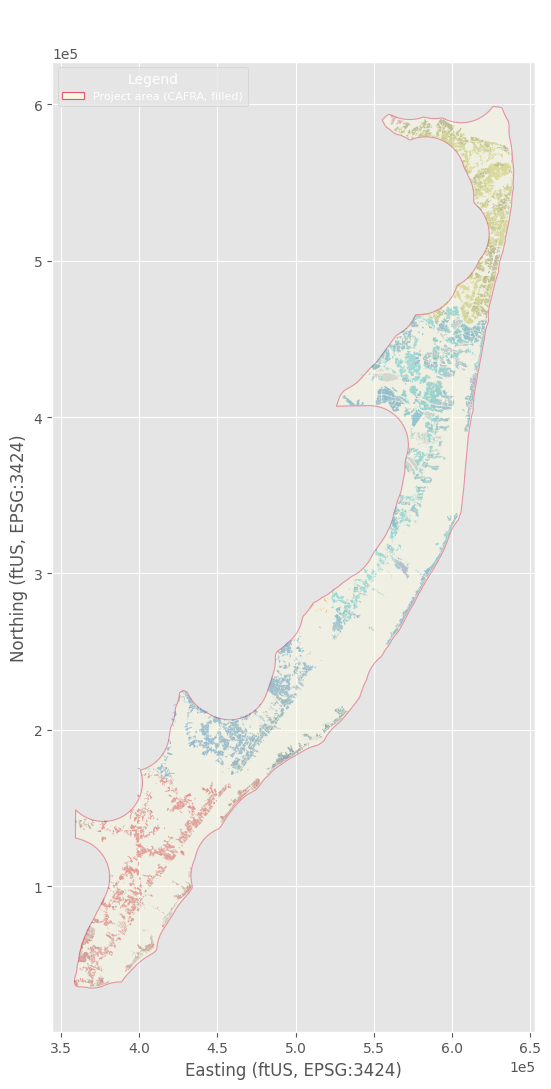

2023 rows: 442,588  |  columns: 169  |  null geom: 0


In [29]:
sample = gpd.read_parquet(SHORE_PATH, filters=[("mod_iv_year", "==", 2023)])
mask_plot = gpd.read_parquet(MASK_PATH).to_crs(sample.crs)

fig, ax = plt.subplots(figsize=(12, 11))

# Project area filled polygon (hole-free CAFRA mask)
mask_plot.plot(ax=ax, facecolor="lightyellow", edgecolor="crimson", linewidth=0.8, alpha=0.4, zorder=1)

# Parcels coloured by county
sample.plot(
    ax=ax,
    column="mod_iv_county_name",
    categorical=True,
    legend=True,
    alpha=0.45,
    edgecolor="none",
    zorder=2,
    legend_kwds={"loc": "upper left", "fontsize": 8, "title": "County"},
)

# Add project area to legend
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="lightyellow", edgecolor="crimson", linewidth=0.8, alpha=0.7))
labels.append("Project area (CAFRA, filled)")
ax.get_legend().remove()
ax.legend(handles, labels, loc="upper left", fontsize=8, title="Legend")

ax.set_title("Jersey Shore parcels — CAFRA boundary filter (holes filled)\n2023 sample", fontsize=11)
ax.set_xlabel("Easting (ftUS, EPSG:3424)")
ax.set_ylabel("Northing (ftUS, EPSG:3424)")
ax.ticklabel_format(style="sci", scilimits=(5, 5), axis="both")
plt.tight_layout()
plt.show()

print(f"2023 rows: {len(sample):,}  |  columns: {sample.shape[1]}  |  null geom: {sample.geometry.isna().sum()}")
del sample